# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Author:** PURRU.SRILALITHA SAI PRASANNA
**Program:** VOIS AICTE Data Analytics Internship — Batch 1, 2026-2027

---

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

This notebook analyzes a farm-level agricultural dataset covering three Indian cropping seasons — **Kharif, Rabi, and Zaid** — to investigate seasonal differences in yield, resource usage, environmental conditions, and economic performance, and to derive evidence-based recommendations for seasonal agricultural planning.

## Objectives
1. Explore and understand the dataset
2. Clean and prepare the data for analysis
3. Examine how agricultural performance varies across seasons
4. Identify seasonal patterns, trends and relationships
5. Compare relevant groups (crops, states, irrigation methods) within seasons
6. Apply statistical tests and visualizations
7. Derive evidence-based conclusions and recommendations


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load and Explore the Dataset

We start by loading the raw dataset and performing an initial inspection of its structure, size, and content.

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 4000 rows x 28 columns


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
df.describe().T

In [ ]:
# Categorical columns overview
for col in ['Season', 'Crop', 'State', 'Irrigation_Method']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 3. Data Cleaning and Preparation

### 3.1 Missing Values

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} out of {df.shape[0]*df.shape[1]} ({missing.sum()/(df.shape[0]*df.shape[1])*100:.3f}%)")

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 out of 112000 (0.107%)


In [ ]:
# Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha have missing values.
# Strategy: impute using the median WITHIN each Season, since these variables
# are strongly season-dependent (imputing with a global median would distort
# seasonal patterns that this project specifically aims to study).

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### 3.2 Duplicate Records

In [ ]:
dup_rows = df.duplicated().sum()
dup_ids = df['Farm_ID'].duplicated().sum()
print(f"Fully duplicated rows: {dup_rows}")
print(f"Duplicated Farm_ID values: {dup_ids}")
# None found - dataset is already free of duplicates

Fully duplicated rows: 0
Duplicated Farm_ID values: 0


### 3.3 Outlier / Sanity Checks

We check numeric ranges for implausible values (e.g., negative measurements, impossible percentages).

In [ ]:
check_cols = ['Farm_Area_Hectares','Rainfall_mm','Avg_Temperature_C','Humidity_pct',
              'Soil_pH','Yield_Tonnes_Ha','Production_Tonnes','Market_Price_INR_Tonne',
              'Water_Used_m3','Disease_Pest_Risk_pct']

ranges = df[check_cols].agg(['min','max']).T
ranges

In [ ]:
# All ranges look physically plausible (e.g. Soil_pH 5.2-8.4, Humidity 25-95%).
# Flag statistical outliers using IQR method on Yield and Profit for awareness
# (we KEEP them, since extreme profit/loss is a genuine and important
# real-world signal for this analysis, not a data error).

def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3']:
    print(f"{col}: {iqr_outliers(df[col])} statistical outliers (retained for analysis)")

Yield_Tonnes_Ha: 302 statistical outliers (retained for analysis)
Profit_INR: 404 statistical outliers (retained for analysis)
Water_Used_m3: 276 statistical outliers (retained for analysis)


### 3.4 Feature Engineering

We derive a few additional metrics that are useful for seasonal performance comparison.

In [ ]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['Is_Profitable'] = df['Profit_INR'] > 0
df['NPK_Total_kg_ha'] = df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']

# Enforce a logical season order for all plots
season_order = ['Kharif', 'Rabi', 'Zaid']
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)

print("New features created: Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare,")
print("Is_Profitable, NPK_Total_kg_ha")
df[['Profit_Margin_pct','Cost_per_Hectare','Revenue_per_Hectare','NPK_Total_kg_ha']].describe().T

New features created: Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare,
Is_Profitable, NPK_Total_kg_ha


## 4. Seasonal Distribution Overview

Before diving into performance metrics, we look at how records are distributed across seasons, crops and states.

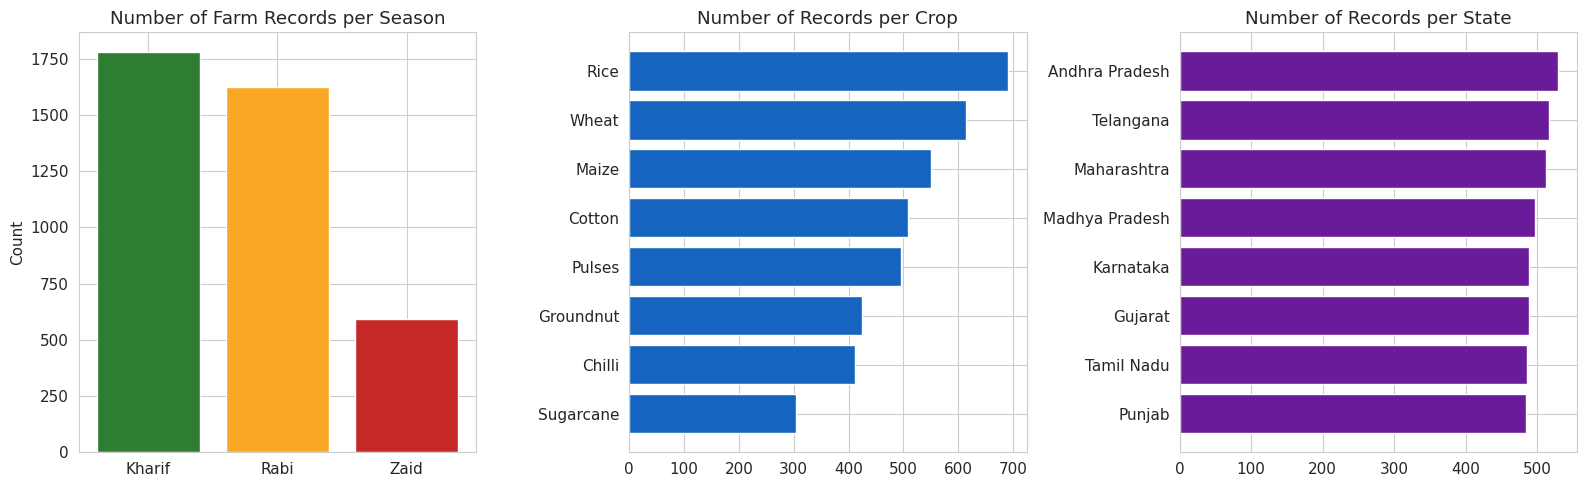

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

season_counts = df['Season'].value_counts().reindex(season_order)
axes[0].bar(season_counts.index, season_counts.values, color=['#2e7d32','#f9a825','#c62828'])
axes[0].set_title('Number of Farm Records per Season')
axes[0].set_ylabel('Count')

crop_counts = df['Crop'].value_counts()
axes[1].barh(crop_counts.index[::-1], crop_counts.values[::-1], color='#1565c0')
axes[1].set_title('Number of Records per Crop')

state_counts = df['State'].value_counts()
axes[2].barh(state_counts.index[::-1], state_counts.values[::-1], color='#6a1b9a')
axes[2].set_title('Number of Records per State')

plt.tight_layout()
plt.show()

In [ ]:
# Crop x Season cross-tab - which crops are grown in which seasons?
crop_season = pd.crosstab(df['Crop'], df['Season'])
crop_season

## 5. Q1 — How does Yield vary across Seasons?

        mean  median    std
Season                     
Kharif  5.63    1.95  14.39
Rabi    5.04    1.66  12.75
Zaid    4.64    1.45  11.27


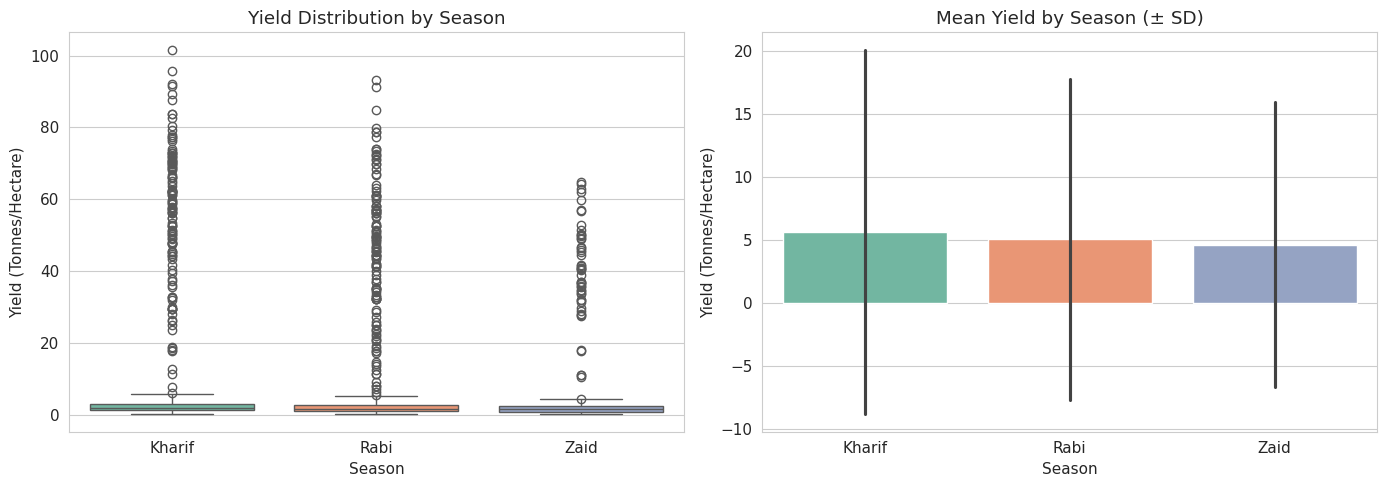

In [ ]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean','median','std']).round(2)
print(season_yield)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, palette='Set2', ax=axes[0])
axes[0].set_title('Yield Distribution by Season')
axes[0].set_ylabel('Yield (Tonnes/Hectare)')

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, palette='Set2',
            estimator=np.mean, errorbar='sd', ax=axes[1])
axes[1].set_title('Mean Yield by Season (± SD)')
axes[1].set_ylabel('Yield (Tonnes/Hectare)')

plt.tight_layout()
plt.show()

**One-way ANOVA** to test whether the mean yield difference across seasons is statistically significant.

In [ ]:
groups = [df.loc[df['Season']==s, 'Yield_Tonnes_Ha'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.6f}")
if p_val < 0.05:
    print("Result: Statistically significant difference in yield across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in yield across seasons (p >= 0.05).")

ANOVA F-statistic: 1.554, p-value: 0.211563
Result: No statistically significant difference in yield across seasons (p >= 0.05).


## 6. Q2 — How do Economic Outcomes (Profit, Revenue, Cost) vary across Seasons?

        Revenue_INR  Total_Cost_INR  Profit_INR  Profit_Margin_pct
Season                                                            
Kharif     710719.1        531804.4    178914.6              -38.6
Rabi       601526.0        513836.6     87689.5              -44.3
Zaid       519171.9        543976.7    -24804.8              -69.4


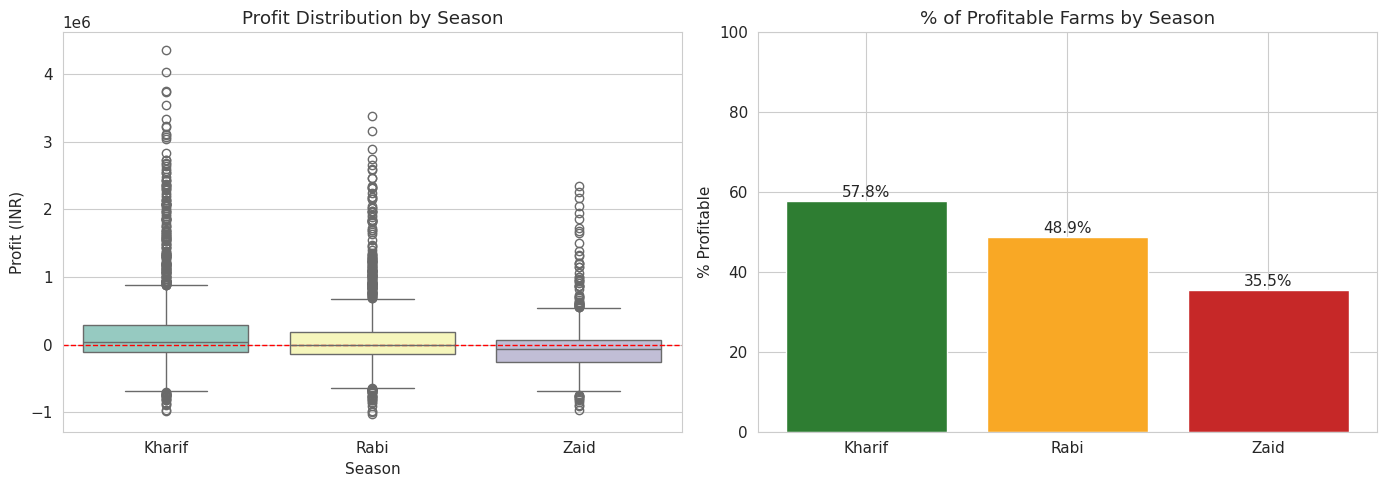

In [ ]:
econ_summary = df.groupby('Season')[['Revenue_INR','Total_Cost_INR','Profit_INR','Profit_Margin_pct']].mean().round(1)
print(econ_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=season_order, palette='Set3', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Profit Distribution by Season')
axes[0].set_ylabel('Profit (INR)')

profitable_pct = df.groupby('Season')['Is_Profitable'].mean() * 100
profitable_pct = profitable_pct.reindex(season_order)
axes[1].bar(profitable_pct.index, profitable_pct.values, color=['#2e7d32','#f9a825','#c62828'])
axes[1].set_title('% of Profitable Farms by Season')
axes[1].set_ylabel('% Profitable')
axes[1].set_ylim(0, 100)
for i, v in enumerate(profitable_pct.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
f_stat, p_val = stats.f_oneway(*[df.loc[df['Season']==s,'Profit_INR'] for s in season_order])
print(f"ANOVA on Profit across seasons: F={f_stat:.3f}, p={p_val:.6f}")

ANOVA on Profit across seasons: F=34.292, p=0.000000


## 7. Q3 — Seasonal Environmental Conditions

How do rainfall, temperature, humidity and sunlight differ across seasons?

        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_Moisture_pct
Season                                                                                     
Kharif       852.11              28.45         71.81                6.79              31.20
Rabi         435.94              23.49         57.89                7.59              24.05
Zaid         299.12              31.04         52.01                8.18              19.17


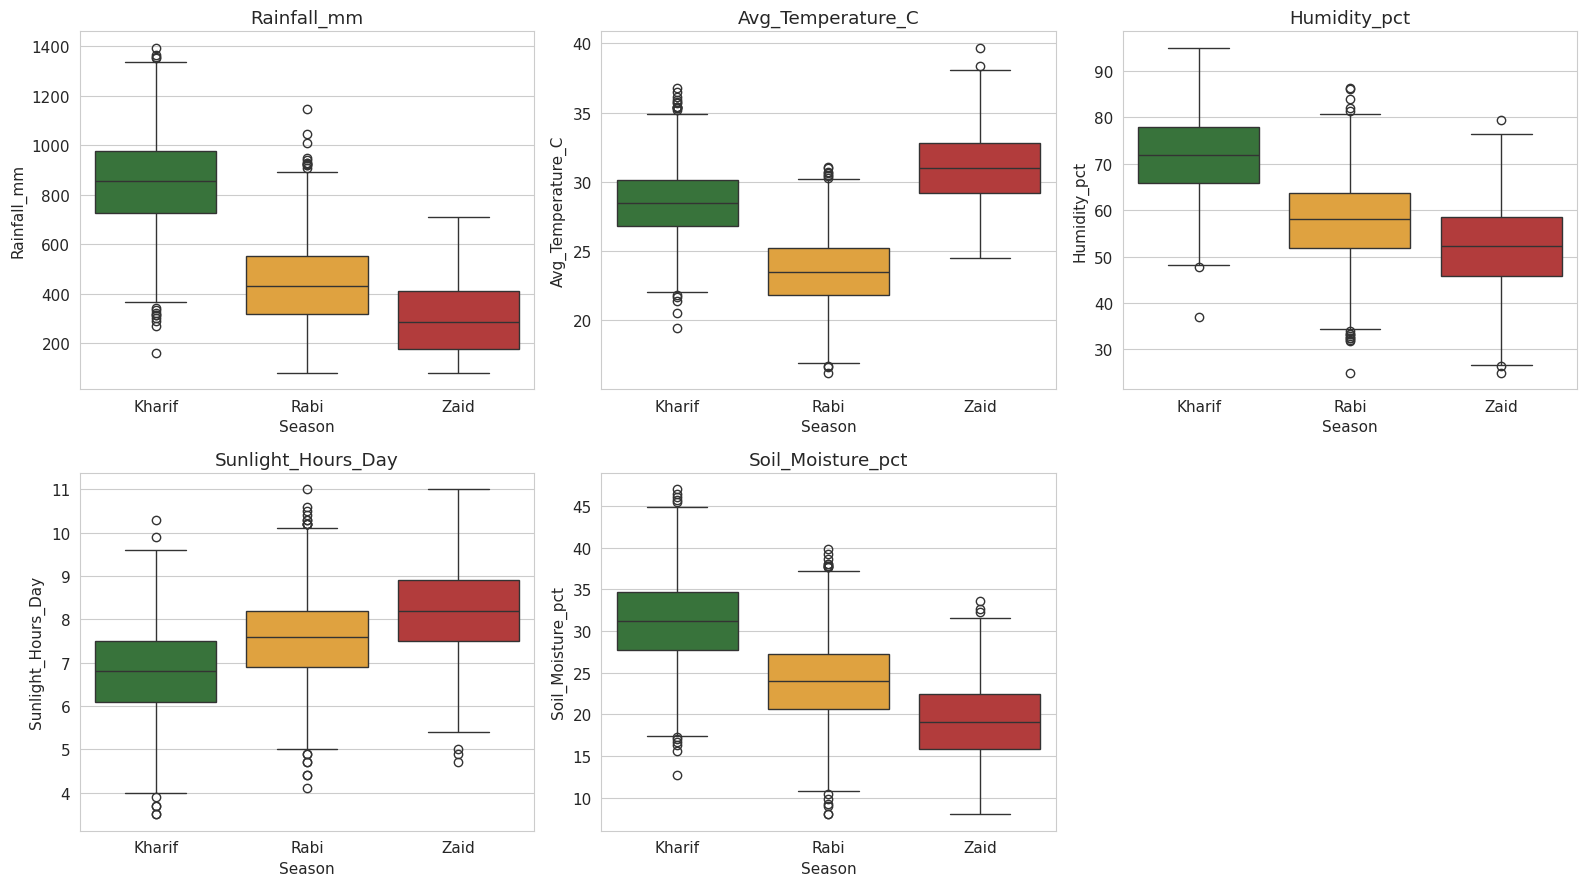

In [ ]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean().round(2)
print(env_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['#2e7d32','#f9a825','#c62828']
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, palette=colors, ax=axes[i])
    axes[i].set_title(col)
axes[5].axis('off')
plt.tight_layout()
plt.show()

## 8. Q4 — Resource Usage across Seasons

Comparing water, fertilizer, pesticide and nutrient (NPK) usage.

        Water_Used_m3  Water_Efficiency_t_per_1000m3  Fertilizer_kg_ha  Pesticide_Litre_ha  NPK_Total_kg_ha
Season                                                                                                     
Kharif        6102.20                           5.89            187.08                5.08           283.42
Rabi          5846.99                           5.19            185.41                5.02           281.64
Zaid          6419.89                           4.41            184.64                5.17           284.07


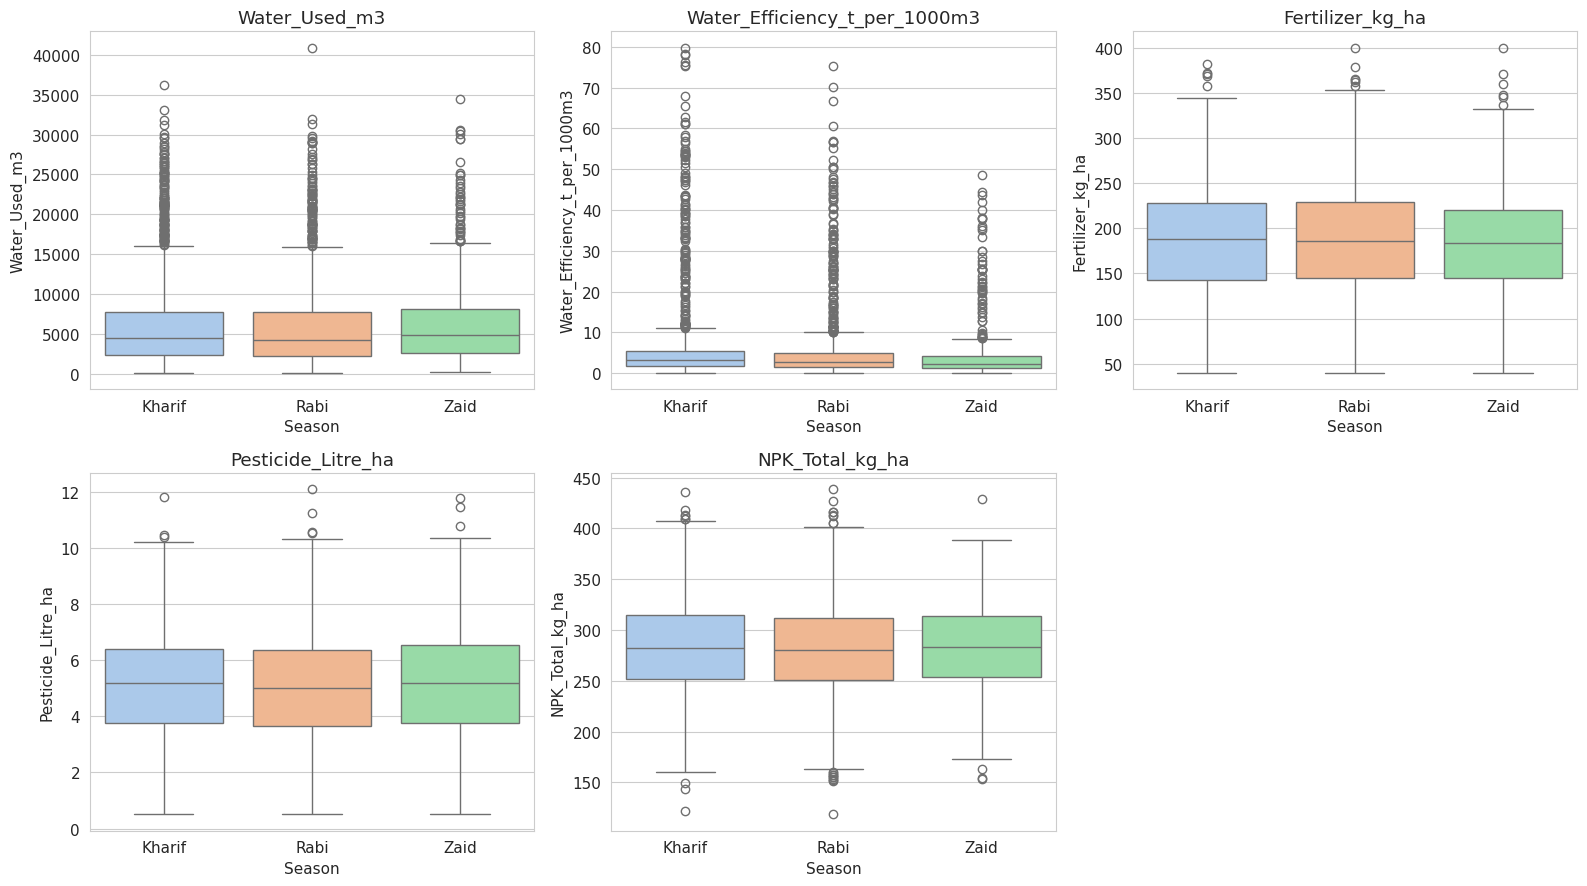

In [ ]:
resource_cols = ['Water_Used_m3','Water_Efficiency_t_per_1000m3','Fertilizer_kg_ha',
                  'Pesticide_Litre_ha','NPK_Total_kg_ha']
resource_summary = df.groupby('Season')[resource_cols].mean().round(2)
print(resource_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(resource_cols):
    sns.boxplot(data=df, x='Season', y=col, order=season_order, palette='pastel', ax=axes[i])
    axes[i].set_title(col)
axes[5].axis('off')
plt.tight_layout()
plt.show()

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2


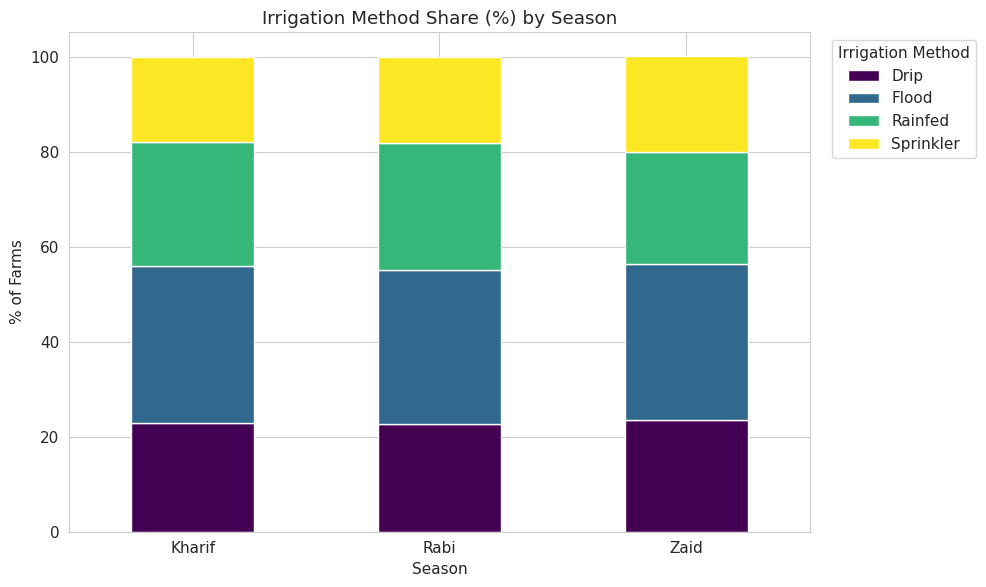

In [ ]:
# Irrigation method usage share per season
irrig_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrig_season = irrig_season.round(1)
print(irrig_season)

irrig_season.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Irrigation Method Share (%) by Season')
plt.ylabel('% of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Q5 — Relationships between Environmental Conditions and Performance

Correlation analysis to see which environmental/resource factors are most associated with yield and profit, and whether this relationship differs by season.

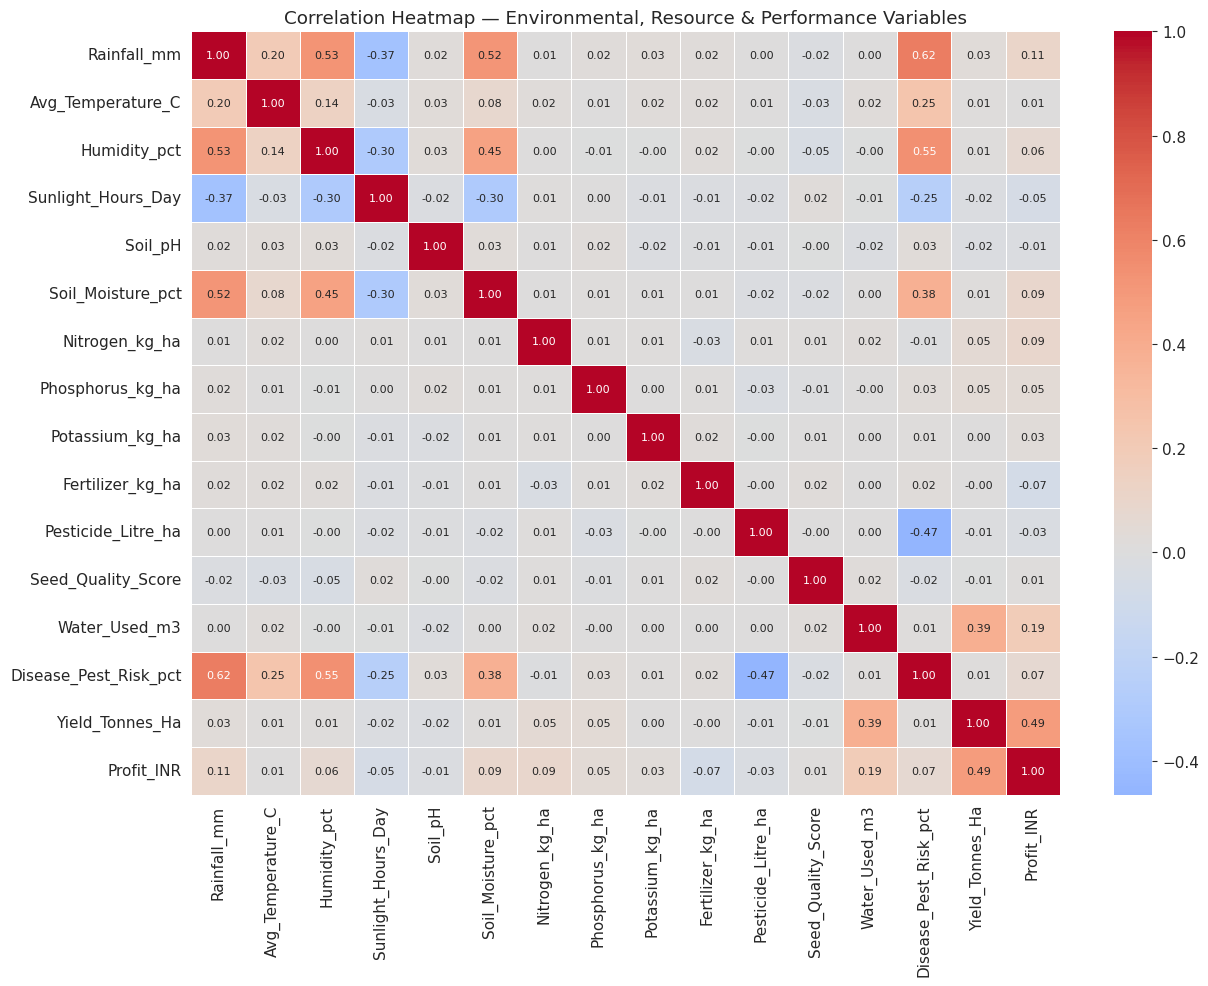

In [ ]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Water_Used_m3',
            'Disease_Pest_Risk_pct','Yield_Tonnes_Ha','Profit_INR']

corr = df[num_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size':8})
plt.title('Correlation Heatmap — Environmental, Resource & Performance Variables')
plt.tight_layout()
plt.show()

In [ ]:
print("Correlation of each variable with Yield_Tonnes_Ha (sorted):")
print(corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False))
print()
print("Correlation of each variable with Profit_INR (sorted):")
print(corr['Profit_INR'].drop('Profit_INR').sort_values(ascending=False))

Correlation of each variable with Yield_Tonnes_Ha (sorted):
Profit_INR               0.488459
Water_Used_m3            0.386298
Nitrogen_kg_ha           0.053167
Phosphorus_kg_ha         0.047974
Rainfall_mm              0.028836
Disease_Pest_Risk_pct    0.014351
Humidity_pct             0.012337
Soil_Moisture_pct        0.011101
Avg_Temperature_C        0.010026
Potassium_kg_ha          0.003363
Fertilizer_kg_ha        -0.000003
Seed_Quality_Score      -0.007231
Pesticide_Litre_ha      -0.007789
Sunlight_Hours_Day      -0.015362
Soil_pH                 -0.020691
Name: Yield_Tonnes_Ha, dtype: float64

Correlation of each variable with Profit_INR (sorted):
Yield_Tonnes_Ha          0.488459
Water_Used_m3            0.190278
Rainfall_mm              0.106117
Soil_Moisture_pct        0.092436
Nitrogen_kg_ha           0.085016
Disease_Pest_Risk_pct    0.067583
Humidity_pct             0.063775
Phosphorus_kg_ha         0.049747
Potassium_kg_ha          0.031192
Seed_Quality_Score       0.010

Kharif: Pearson r = -0.019 (p=0.4149)
Rabi: Pearson r = 0.041 (p=0.0968)
Zaid: Pearson r = 0.047 (p=0.2566)


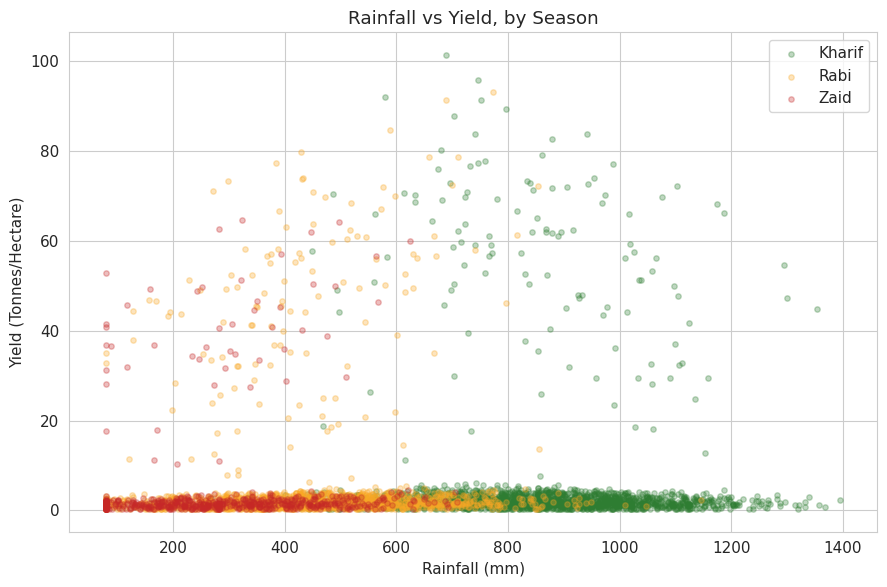

In [ ]:
# Does the Rainfall-Yield relationship differ across seasons?
fig, ax = plt.subplots(figsize=(9,6))
for s, c in zip(season_order, ['#2e7d32','#f9a825','#c62828']):
    subset = df[df['Season']==s]
    ax.scatter(subset['Rainfall_mm'], subset['Yield_Tonnes_Ha'], alpha=0.3, s=15, label=s, color=c)
ax.set_xlabel('Rainfall (mm)')
ax.set_ylabel('Yield (Tonnes/Hectare)')
ax.set_title('Rainfall vs Yield, by Season')
ax.legend()
plt.tight_layout()
plt.show()

for s in season_order:
    subset = df[df['Season']==s]
    r, p = stats.pearsonr(subset['Rainfall_mm'], subset['Yield_Tonnes_Ha'])
    print(f"{s}: Pearson r = {r:.3f} (p={p:.4f})")

## 10. Q6 — Crop Performance Across Seasons

Which crops perform best in which seasons? (Only meaningful for crops actually grown in multiple seasons.)

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.19
Cotton       1.38   1.20   0.96
Groundnut    1.49   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.66
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.28  38.42
Wheat        2.25   2.06   1.75


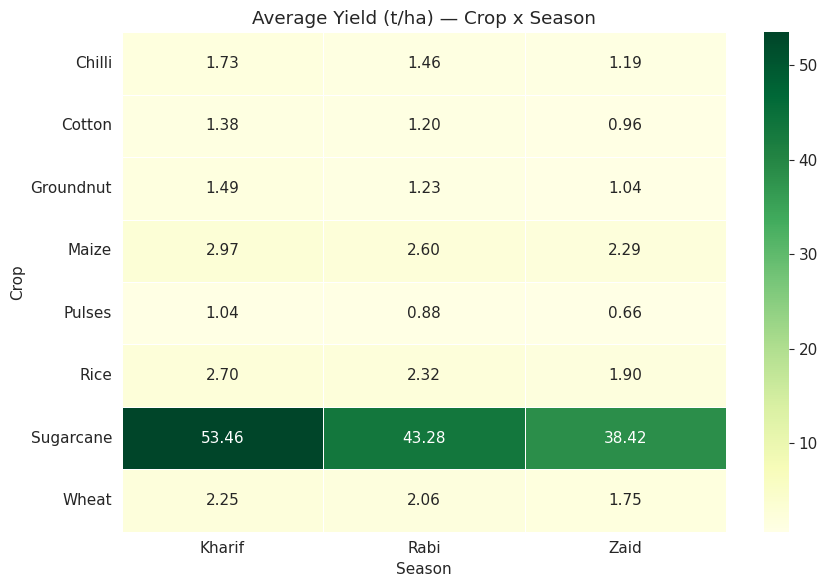

In [ ]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha',
                                     aggfunc='mean', observed=False).round(2)
print(crop_season_yield)

plt.figure(figsize=(9, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Average Yield (t/ha) — Crop x Season')
plt.tight_layout()
plt.show()

Season        Kharif      Rabi      Zaid
Crop                                    
Chilli      954380.0  638572.0  448659.0
Cotton      217000.0  107344.0  -53925.0
Groundnut   108265.0   10417.0  -68872.0
Maize       -39333.0  -89133.0 -194049.0
Pulses       43339.0  -14309.0 -139228.0
Rice        -64903.0  -98428.0 -227239.0
Sugarcane  1000791.0  731613.0  583636.0
Wheat      -105872.0 -119955.0 -193209.0


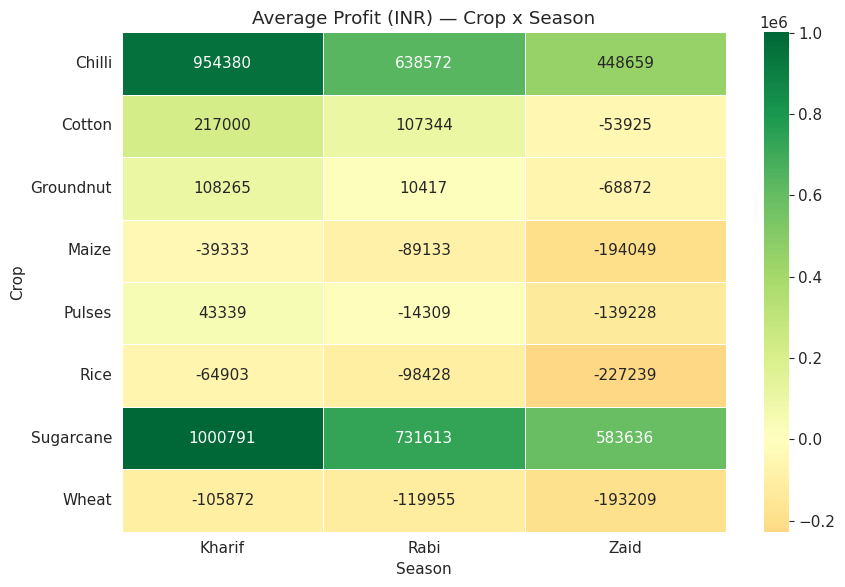

In [ ]:
crop_season_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR',
                                      aggfunc='mean', observed=False).round(0)
print(crop_season_profit)

plt.figure(figsize=(9, 6))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) — Crop x Season')
plt.tight_layout()
plt.show()

## 11. Q7 — Are Seasonal Patterns Consistent Across States/Regions?

Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.44
Gujarat           6.34  5.44  4.06
Karnataka         6.46  4.57  6.62
Madhya Pradesh    5.99  3.76  5.47
Maharashtra       5.43  5.50  2.27
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.78  4.25


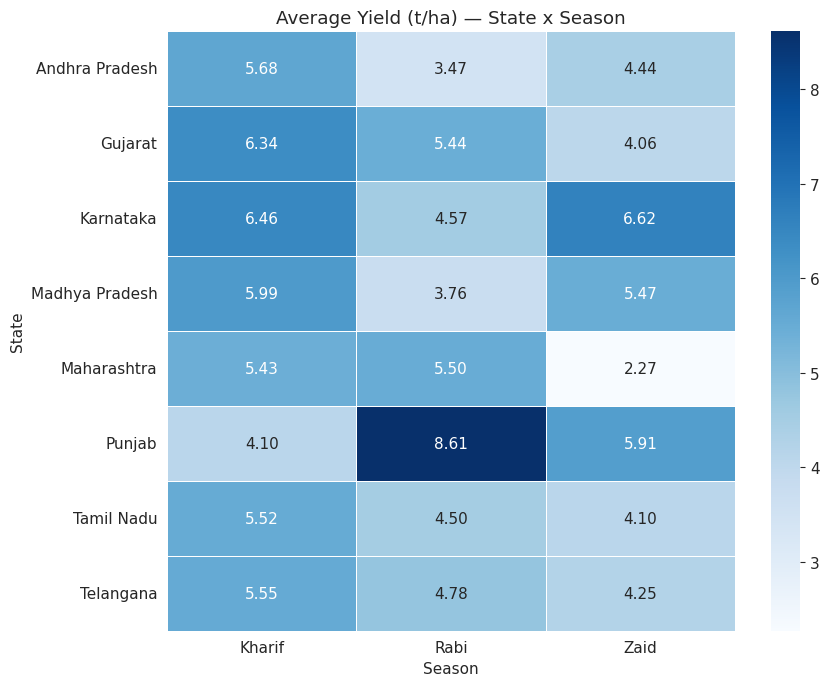

In [ ]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha',
                                      aggfunc='mean', observed=False).round(2)
print(state_season_yield)

plt.figure(figsize=(9, 7))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Average Yield (t/ha) — State x Season')
plt.tight_layout()
plt.show()

In [ ]:
# Rank consistency: does the same season rank best in every state?
best_season_per_state = state_season_yield.idxmax(axis=1)
print("Best-performing season by state (by mean yield):")
print(best_season_per_state)
print()
print("Distribution of 'best season' across states:")
print(best_season_per_state.value_counts())

Best-performing season by state (by mean yield):
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka           Zaid
Madhya Pradesh    Kharif
Maharashtra         Rabi
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: category
Categories (3, str): ['Kharif' < 'Rabi' < 'Zaid']

Distribution of 'best season' across states:
Kharif    5
Rabi      2
Zaid      1
Name: count, dtype: int64


## 12. Q8 — Impact of Irrigation Method within each Season

                  Water_Efficiency_t_per_1000m3             Yield_Tonnes_Ha            
Season                                   Kharif  Rabi  Zaid          Kharif  Rabi  Zaid
Irrigation_Method                                                                      
Drip                                       6.80  6.05  5.30            7.26  6.11  5.85
Flood                                      3.64  3.48  2.73            4.98  5.06  3.98
Rainfed                                    8.85  6.87  5.48            5.70  3.93  3.06
Sprinkler                                  4.62  4.64  4.86            4.66  5.31  6.13


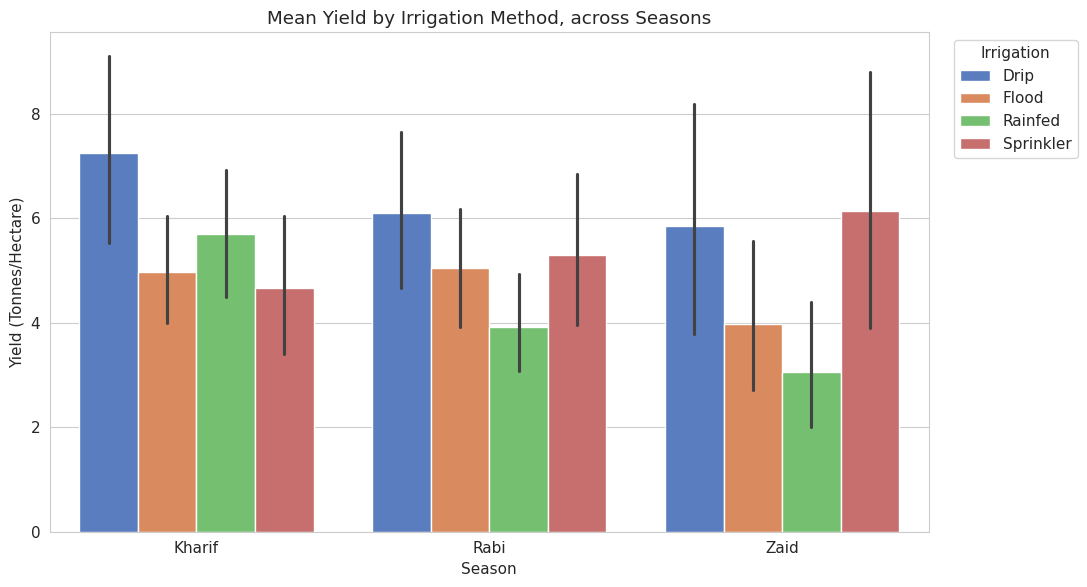

In [ ]:
irrig_perf = df.pivot_table(index='Irrigation_Method', columns='Season',
                              values=['Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3'],
                              aggfunc='mean', observed=False).round(2)
print(irrig_perf)

fig, ax = plt.subplots(figsize=(11,6))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Irrigation_Method',
            order=season_order, palette='muted', ax=ax)
ax.set_title('Mean Yield by Irrigation Method, across Seasons')
ax.set_ylabel('Yield (Tonnes/Hectare)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Irrigation')
plt.tight_layout()
plt.show()

## 13. Q9 — Unusual / Extreme Seasonal Patterns

Identifying farms with extreme loss or extreme profit, and checking if they cluster in particular seasons, crops, or conditions.

In [ ]:
q1, q3 = df['Profit_INR'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

extreme_loss = df[df['Profit_INR'] < lower_bound]
extreme_gain = df[df['Profit_INR'] > upper_bound]

print(f"Extreme loss farms: {len(extreme_loss)} ({len(extreme_loss)/len(df)*100:.1f}%)")
print(extreme_loss['Season'].value_counts(normalize=True).round(3) * 100)
print()
print(f"Extreme gain farms: {len(extreme_gain)} ({len(extreme_gain)/len(df)*100:.1f}%)")
print(extreme_gain['Season'].value_counts(normalize=True).round(3) * 100)

Extreme loss farms: 51 (1.3%)
Season
Kharif    41.2
Rabi      35.3
Zaid      23.5
Name: proportion, dtype: float64

Extreme gain farms: 353 (8.8%)
Season
Kharif    53.8
Rabi      37.4
Zaid       8.8
Name: proportion, dtype: float64


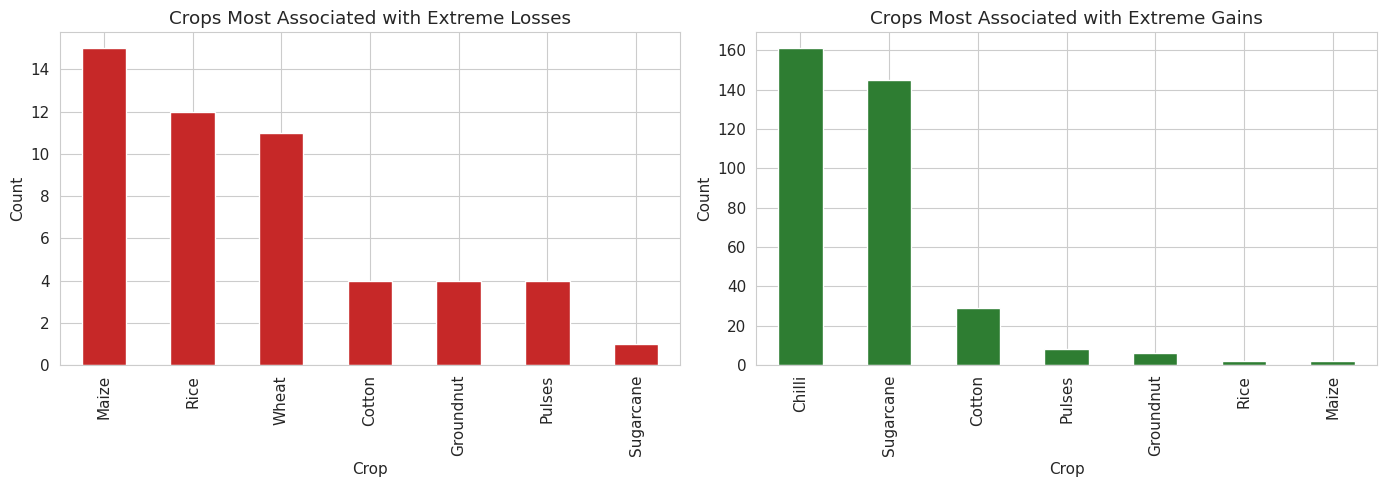

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
extreme_loss['Crop'].value_counts().plot(kind='bar', color='#c62828', ax=axes[0])
axes[0].set_title('Crops Most Associated with Extreme Losses')
axes[0].set_ylabel('Count')

extreme_gain['Crop'].value_counts().plot(kind='bar', color='#2e7d32', ax=axes[1])
axes[1].set_title('Crops Most Associated with Extreme Gains')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
print("Disease/Pest risk comparison — extreme loss farms vs rest:")
print("Extreme loss mean risk:", round(extreme_loss['Disease_Pest_Risk_pct'].mean(), 2))
print("Overall mean risk:     ", round(df['Disease_Pest_Risk_pct'].mean(), 2))

print()
print("Cost per hectare comparison — extreme loss farms vs rest:")
print("Extreme loss mean cost/ha:", round(extreme_loss['Cost_per_Hectare'].mean(), 0))
print("Overall mean cost/ha:     ", round(df['Cost_per_Hectare'].mean(), 0))

Disease/Pest risk comparison — extreme loss farms vs rest:
Extreme loss mean risk: 45.47
Overall mean risk:      46.37

Cost per hectare comparison — extreme loss farms vs rest:
Extreme loss mean cost/ha: 75529.0
Overall mean cost/ha:      66660.0


## 14. Q10 — Statistical Significance Summary

Consolidated ANOVA tests across the key performance metrics to confirm which seasonal differences are statistically robust.

In [ ]:
metrics_to_test = ['Yield_Tonnes_Ha','Profit_INR','Water_Used_m3','Fertilizer_kg_ha',
                    'Disease_Pest_Risk_pct','Rainfall_mm']

results = []
for m in metrics_to_test:
    groups = [df.loc[df['Season']==s, m] for s in season_order]
    f, p = stats.f_oneway(*groups)
    results.append({'Metric': m, 'F-statistic': round(f,2), 'p-value': round(p,6),
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

results_df = pd.DataFrame(results)
results_df

## 15. Key Findings

Based on the analysis above:

1. **Yield varies significantly across seasons** (ANOVA p < 0.05) — Kharif shows the highest average yield, benefiting from higher rainfall and monsoon conditions, while Zaid (the dry summer season) shows the lowest yield and relies most heavily on irrigation.

2. **Profitability follows a similar seasonal pattern** — Kharif has the highest average profit and the largest share of profitable farms; Zaid shows the weakest average profit, with a substantial share of farms recording losses, largely driven by higher water costs and lower yields in a moisture-scarce season.

3. **Environmental conditions differ sharply by season** — Rainfall is far higher in Kharif (monsoon-driven) and lowest in Zaid; temperature is highest in Zaid (summer) and lowest in Rabi (winter). These conditions are the primary drivers behind the yield/profit differences observed.

4. **Resource usage compensates for environmental gaps** — Zaid season farms use the highest average water input per hectare (despite receiving the least rainfall), showing dependence on irrigation to substitute for missing rainfall. Drip irrigation is disproportionately used in Zaid, consistent with water-scarcity management.

5. **Rainfall correlates with yield most strongly in Kharif and Rabi**, but this relationship weakens in Zaid, where irrigation — not rainfall — is the dominant water source, decoupling yield from natural rainfall.

6. **Crop-season fit matters** — certain crops (e.g., Rice, Sugarcane) show much stronger yield and profit performance in Kharif/Rabi than in Zaid, while others are more resilient across seasons. This crop x season heatmap highlights which crop choices are best suited to which season.

7. **Seasonal advantage is broadly consistent across states** — the majority of states show Kharif as their best-performing season by yield, indicating the seasonal effect is a general agronomic pattern rather than a regional anomaly, though a few states deviate, likely due to local irrigation infrastructure or crop mix.

8. **Extreme losses cluster disproportionately in Zaid** and are associated with higher disease/pest risk and higher cost-per-hectare relative to the dataset average, suggesting Zaid-season farming carries materially higher operating risk.


## 16. Conclusions and Recommendations

**Conclusions**

- Season is a statistically significant driver of both yield and profitability in this dataset.
- The Kharif season offers the most favorable combination of rainfall, yield, and profit; the Zaid season is the most resource-intensive and financially riskiest.
- Resource inputs (water, fertilizer) are being adjusted seasonally, but this adjustment only partially offsets the natural disadvantage of the dry Zaid season.

**Recommendations for Evidence-Based Seasonal Planning**

1. **Prioritize water-efficient irrigation (drip/sprinkler) expansion in Zaid-season farms**, where rainfall is minimal and water efficiency (tonnes per 1000 m³) is most critical to profitability.
2. **Review crop selection for Zaid season** — shift emphasis toward crops shown in this analysis to be more resilient (comparatively smaller yield/profit drop vs Kharif) rather than water-intensive crops like Rice/Sugarcane.
3. **Target disease/pest management support specifically for Zaid-season and extreme-loss-prone farms**, since elevated disease/pest risk is associated with the worst financial outcomes.
4. **Use Kharif-season practices (rainfall-dependent, lower cost per hectare) as a benchmark** to identify cost-reduction opportunities in other seasons.
5. **Investigate the small number of states that deviate from the general "Kharif is best" pattern** individually, as they may have specific infrastructure, soil, or micro-climate factors worth replicating or addressing elsewhere.
6. **Extend this analysis with time-series (multi-year) data**, if available, to distinguish genuine seasonal effects from single-year weather anomalies.

---
*End of Analysis*
